#  4.1 NumPy的ndarray：⼀种多维数组对象

In [ ]:
import numpy as np


In [ ]:
arr_1 = np.random.randn(10)
arr_1

In [ ]:
arr_1_slice = arr_1[5:8]
arr_1_slice

In [ ]:
arr_1_slice[:] = 99
arr_1_slice

In [ ]:
arr_1

In [ ]:
arr_2_pre_1 = np.random.rand(2,3,3)
arr_2_pre_1


In [ ]:
arr_2_pre_2 = arr_2_pre_1 * 10
arr_2_pre_2

In [ ]:
arr_2 = arr_2_pre_2.astype(int)  # 将整个数组的元素转换为整数
arr_2

In [ ]:
arr_2[0]

In [ ]:
old_value = arr_2[0].copy()
old_value

In [ ]:
arr_2[0] = 42
arr_2

In [ ]:
a = arr_2[1:, 1:, 0:2]

In [ ]:
a.shape

##布尔型索引

###布尔型数组的⻓度必须跟被索引的轴⻓度⼀致。

In [ ]:
names = np.array(['Alice', 'Bob', 'Charlie', 'Diana'])
data = np.random.randn(4, 4)
names

In [ ]:
data

In [ ]:
names == 'Bob'

In [ ]:
data[names == 'Bob',names == 'Alice']

In [ ]:
mask = (names == 'Bob') | (names == 'Diana') & (names != 'Alice')
mask

In [ ]:
names

In [ ]:
names.shape

##花式索引

In [ ]:
arr_3 = np.empty((8, 4))
for i in range(8):
    for j in range(4):
        arr_3[i, j] = i + j
arr_3

In [ ]:
arr_3[[4, 3, 0, 6]]  # 选择第 4、3、0 和 6 行

In [ ]:
arr_3[[-3]]

In [ ]:
arr_4 = np.arange(32).reshape((8, 4))
arr_4

In [ ]:
arr_4[[1, 5, 7], [0, 3, 1]]  # 选择 (1,0), (5,3), (7,1) 位置的元素

##数组转置和轴对换

.T（二维）    .transpose（多维的）

In [ ]:
arr_5 = np.arange(15).reshape((3, 5))
arr_5

In [ ]:
arr_5.T

In [ ]:
np.dot(arr_5, arr_5.T)

In [ ]:
arr_6 = np.arange(16).reshape((2, 2, 4))
arr_6

In [ ]:
arr_6.transpose((1, 0, 2))

# 4.2 通⽤函数：快速的元素级数组函数
通⽤函数（即ufunc）是⼀种对ndarray中的数据执⾏元素级运
算的函数。你可以将其看做简单函数（接受⼀个或多个标量
值，并产⽣⼀个或多个标量值）的⽮量化包装器。

In [ ]:
a = np.random.randn(4)
a

In [ ]:
b = np.random.randn(4)
b

In [ ]:
np.maximum(a, b)  # 元素级最大值

##常用函数

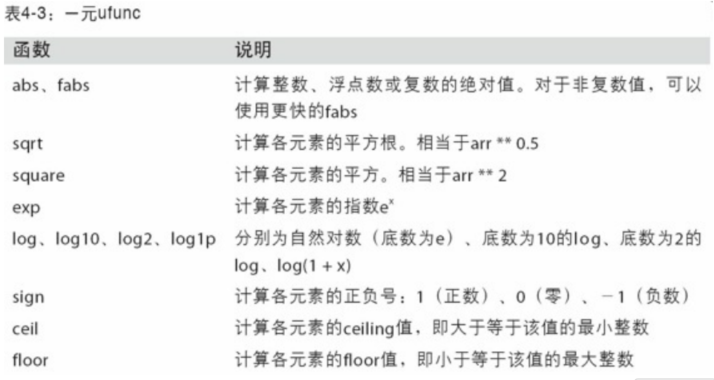
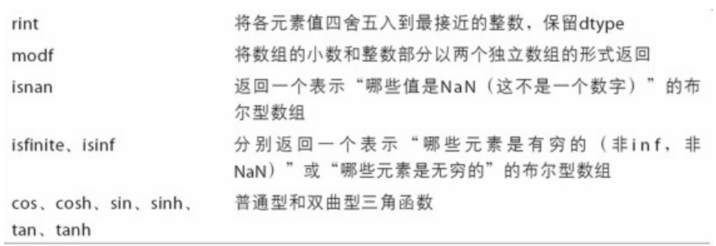
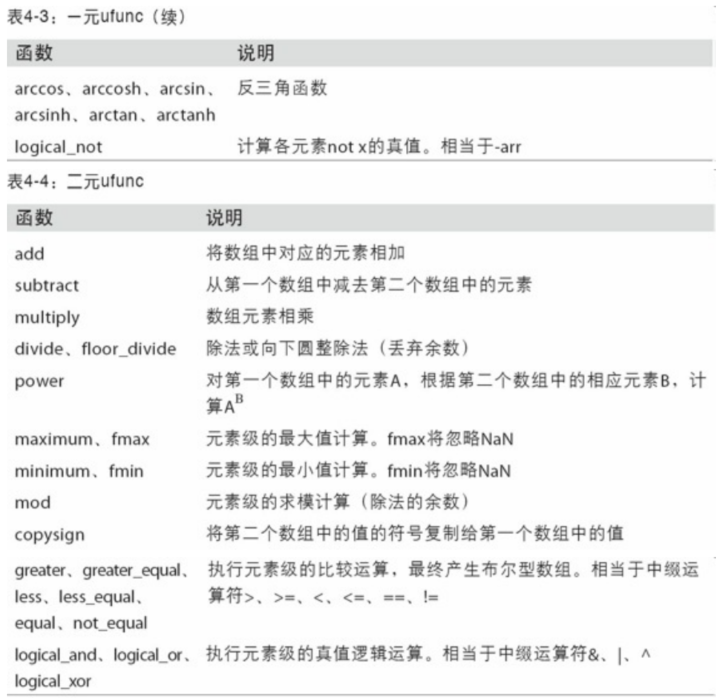


# 4.3 利⽤数组进⾏数据处理

In [ ]:
import numpy as np
points_1 = np.arange(-5, 5, 0.1)
points_2 = np.arange(-5, 5, 0.2)
xs, ys = np.meshgrid(points_1, points_2)
xs

In [ ]:
ys

In [ ]:
z = np.sqrt(xs**2 + ys**2)
z

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray); plt.colorbar()

## 将条件逻辑表述为数组运算

In [ ]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

In [ ]:
# 这有⼏个问题。第⼀，它对⼤数组的处理速度不是很快（因为所有⼯作都是由纯Python完成的）。第⼆，⽆法⽤于多维数组。
# 若使⽤np.where，则可以将该功能写得⾮常简洁：
result = [x if c else y for x, y, c in zip(xarr, yarr, cond)]
result

In [ ]:
# np.where的第⼆个和第三个参数不必是数组，它们都可以是标量值。
# 在数据分析⼯作中，where通常⽤于根据另⼀个数组⽽产⽣⼀个新的数组。
result = np.where(cond, xarr, yarr)
result

In [ ]:
arr4_1 = np.random.randn(8,4)
arr4_1

In [ ]:
arr4_1 > 0

In [ ]:
np.where(arr4_1 > 0, 2, -2)  # 正数替换为2，负数替换为-2

In [ ]:
np.where(arr4_1 > 0, 2, arr4_1)

## 数学和统计⽅法

可以通过数组上的⼀组数学函数对整个数组或某个轴向的数据
进⾏统计计算。sum、mean以及标准差std等聚合计算
（aggregation，通常叫做约简（reduction））既可以当做数
组的实例⽅法调⽤，也可以当做顶级NumPy函数使⽤。

In [ ]:
arr4_2 = np.random.randn(7,4)
arr4_2

In [ ]:
arr4_2.mean(axis=0)

In [ ]:
np.mean(arr4_2)

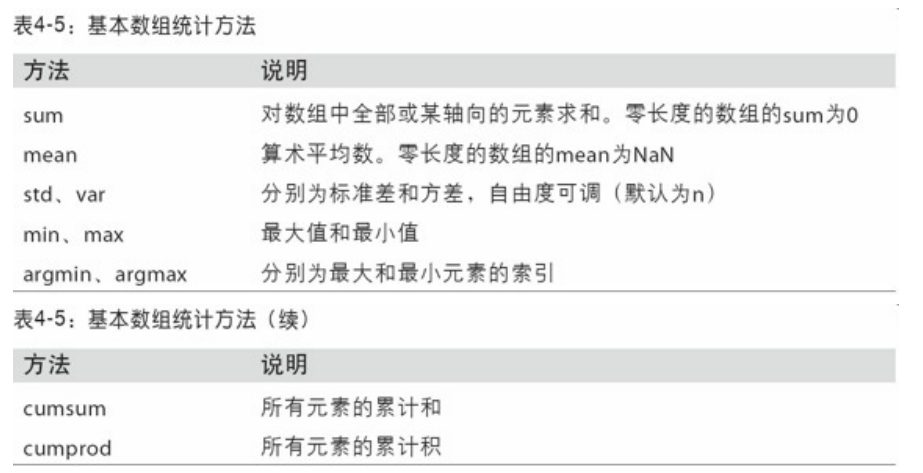

## ⽤于布尔型数组的⽅法

In [ ]:
arr4_3 = np.random.randn(100)
(arr4_3 > 0).sum()  # 计算正数的个数

In [ ]:
arr4_3.any()  # 是否存在⼀个或多个满足条件的元素

In [ ]:
# 另外还有两个⽅法any和all，它们对布尔型数组⾮常有⽤。
# any⽤于测试数组中是否存在⼀个或多个True，⽽all则检查数组中所有值是否都是True
# 这两个⽅法也能⽤于⾮布尔型数组，所有⾮0元素将会被当做True。

arr4_4 = np.array([0, 1, 2, 3, 4])
arr4_4.any()  # 是否所有元素都满足条件

## 排序

跟Python内置的列表类型⼀样，NumPy数组也可以通过sort⽅
法就地排序

In [ ]:
arr4_5 = np.random.randn(8)
arr4_5.sort()
arr4_5

In [ ]:
# 多维数组可以在任何⼀个轴向上进⾏排序，只需将轴编号传给sort即可
arr4_6 = np.random.randn(5, 3)
arr4_6.sort(0)  # 按行排序
arr4_6.sort(1)  # 按列排序
arr4_6

In [ ]:
# 顶级⽅法np.sort返回的是数组的已排序副本，⽽就地排序则会修改数组本⾝。
# 计算数组分位数最简单的办法是对其进⾏排序，然后选取特定位置的值
arr4_7 = np.random.randn(20)
arr4_7.sort()   
arr4_7



In [ ]:
arr4_7[int(0.01 * len(arr4_7))]  # 75% 分位数

## 唯⼀化以及其它的集合逻辑

NumPy提供了⼀些针对⼀维ndarray的基本集合运算。最常⽤
的可能要数np.unique了，它⽤于找出数组中的唯⼀值并返回
已排序的结果

In [ ]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
np.unique(names)

In [ ]:
sorted(set(names))  # 使用Python内置的set函数也能达到同样的效果

In [ ]:
names4_1 = np.array(['Bob', 'Joe'])
np.in1d(names, names4_1)  # 测试names中的每个值是否都包含在names4_1中

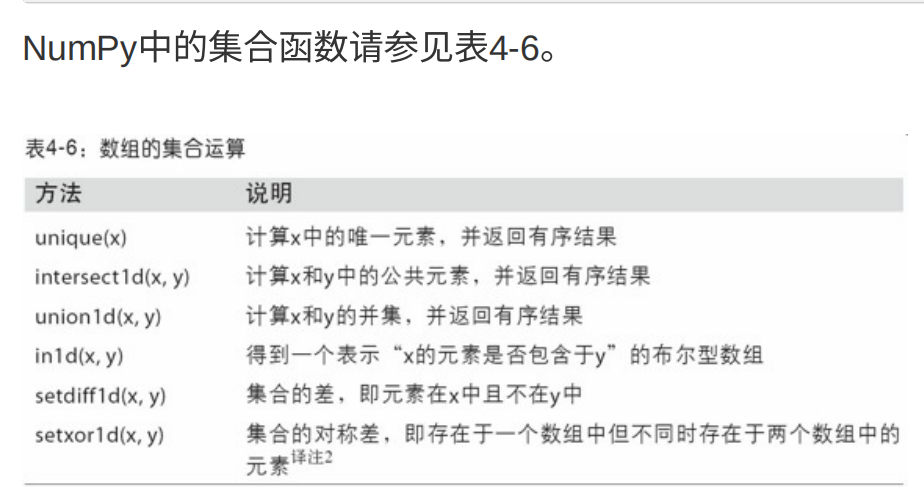

# 4.4 ⽤于数组的⽂件输⼊输出

np.save和np.load是读写磁盘数组数据的两个主要函数。默认
情况下，数组是以未压缩的原始⼆进制格式保存在扩展名
为.npy的⽂件中的

In [ ]:
arr4_8 = np.arange(6)
np.save('my_array.npy', arr4_8)
arr4_9 = np.load('my_array.npy')
arr4_9

In [ ]:
# 通过np.savez可以将多个数组保存到⼀个未压缩⽂件中，将数组以关键字参数的形式传⼊即可
np.savez('array_archive.npz', a=arr4_7, b=arr4_9)


In [ ]:
arch = np.load('array_archive.npz')
arch['b']


In [ ]:
# 如果数据压缩的很好，就可以使⽤np.savez_compressed来节省磁盘空间。
np.savez_compressed('array_archive_compressed.npz', a=arr4_7, b=arr4_9)

## 4.5 线性代数

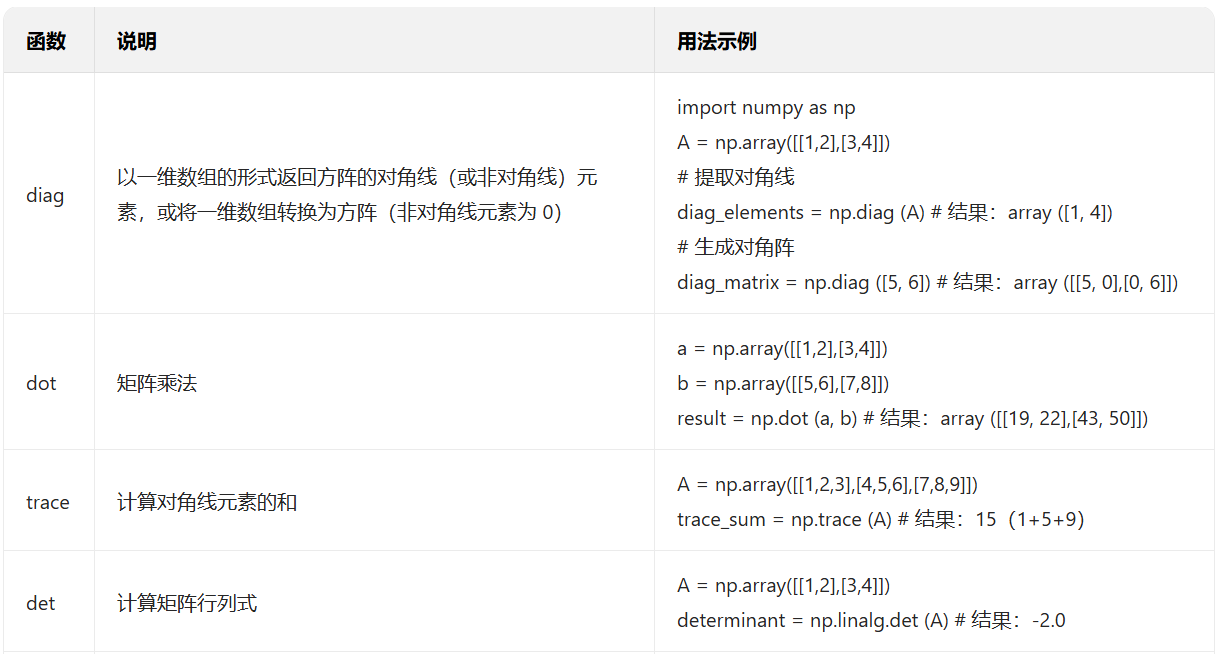
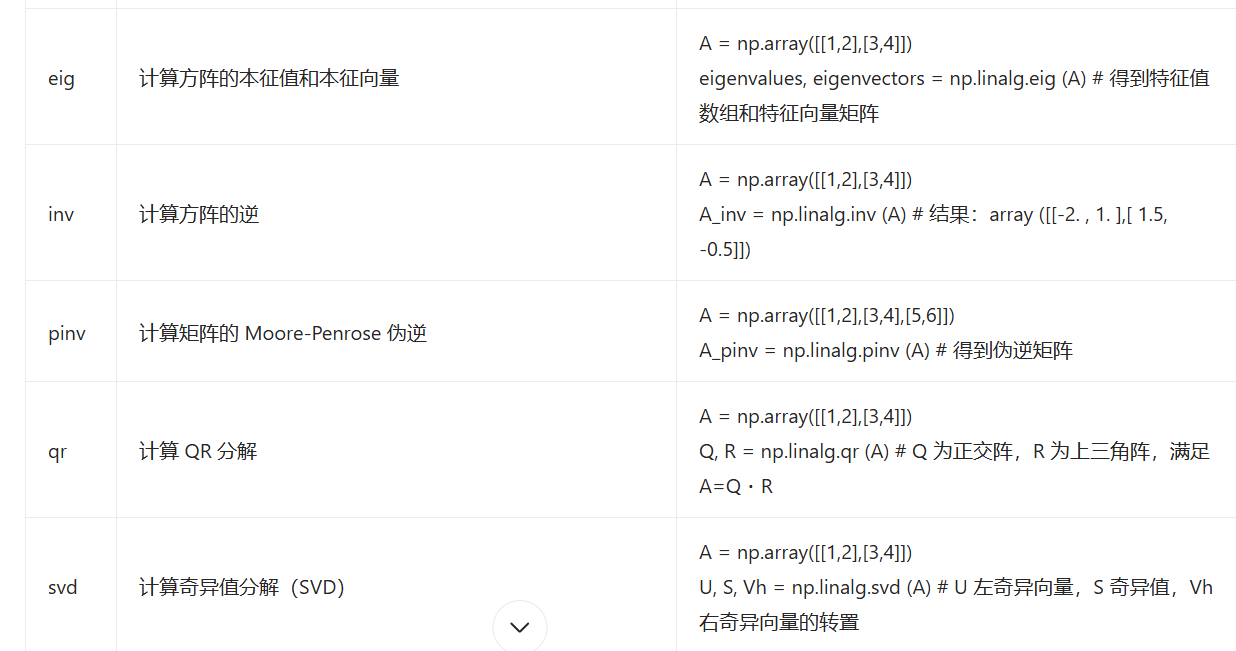
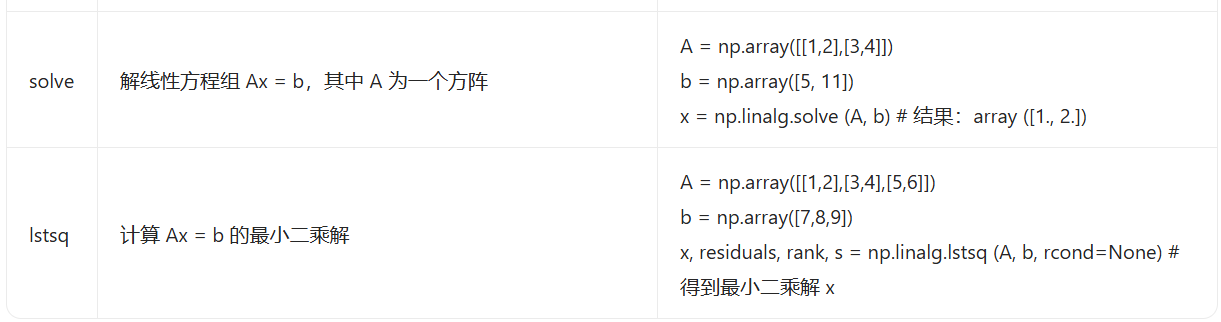




# 4.6 伪随机数⽣成

In [ ]:
# numpy.random模块对Python内置的random进⾏了补充，增加了⼀些⽤于⾼效⽣成多种概率分布的样本值的函数。
# 例如，你可以⽤normal来得到⼀个标准正态分布的4×4样本数组

samples = np.random.normal(size=(4, 4))
samples
np.mo

In [ ]:
from random import normalvariate
n = 1000000
%timeit samples = [normalvariate(0, 1) for _ in range(n)]


In [ ]:
%timeit np.random.normal(size=n)

In [ ]:
# 我们说这些都是伪随机数，是因为它们都是通过算法基于随机数⽣成器种⼦，在确定性的条件下⽣成的
# 你可以⽤NumPy的np.random.seed更改随机数⽣成种⼦
np.random.seed(1234)
rng = np.random.RandomState(1234)
rng.randn(10)

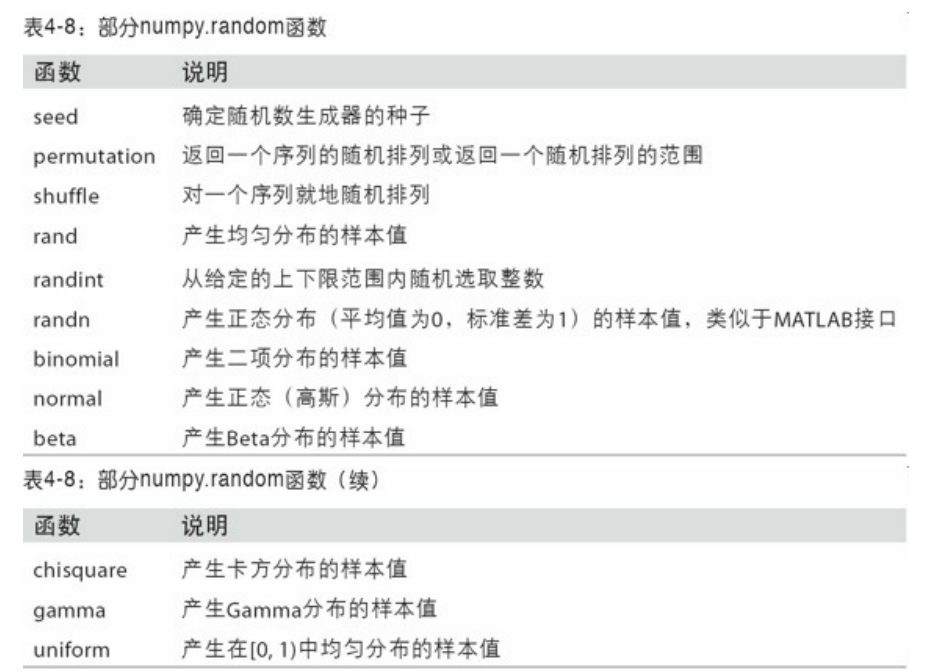

# 4.7 ⽰例：随机漫步

我们通过模拟随机漫步来说明如何运⽤数组运算。先来看⼀个
简单的随机漫步的例⼦：从0开始，步⻓1和－1出现的概率相
等。
下⾯是⼀个通过内置的random模块以纯Python的⽅式实现
1000步的随机漫步

In [ ]:
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    if random.randint(0, 1):
        step = 1
    else:
        step = -1
    position += step
    walk.append(position)
plt.plot(walk[:100])  # 只绘制前100步

In [ ]:
import numpy as np
nsteps = 1000
draws = np.random.randint(0, 2, size=nsteps)
steps = np.where(draws > 0, 1, -1)
walk = steps.cumsum()
walk.min()


In [ ]:
# 注意，这⾥使⽤argmax并不是很⾼效，因为它⽆论如何都会对数组进⾏完全扫描。在本例中，只要发现了⼀个True，那我们就知道它是个最⼤值了
(np.abs(walk) >= 10).argmax()  # 第⼀次到达10或-10的位置

## ⼀次模拟多个随机漫步

In [ ]:
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps))
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(axis=1)
walks

In [ ]:
walks.max()

In [ ]:
walks.min()

In [ ]:
hits30 = (np.abs(walks) >= 30).any(1)
hits30

In [ ]:
# hits30 是一个布尔数组，表示每个随机漫步是否曾达到 |位置| >= 30
# 使用 sum() 会将 True 当作 1 累加，得到达到阈值的漫步数量
num_hits = hits30.sum()
num_hits

In [ ]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(0)
# crossing_times 包含每个达到阈值的漫步首次达到 |位置| >= 30 的步数（索引）。
# 这里使用 argmax 是因为 (np.abs(...) >= 30) 在首次满足时为 True，argmax 返回该第一个 True 的索引。
# 计算这些首次越过阈值步数的平均值。
crossing_times.mean()

In [ ]:
np.abs(walks[hits30])

In [ ]:
# 生成服从均值0、标准差1的正态分布步长，形状为 (nwalks, nsteps)
steps = np.random.normal(loc=0, scale=1, size=(nwalks, nsteps))
steps

# 习题

In [2]:
# 生成一个 3×4 的数组 arr，元素为 0~11，改成形状 2×6，然后取第 2 行的前 3 个元素。
# 提示：np.arange / reshape / 切片。
# 验证：输出形状与切片值。
import numpy as np
arr5_1 = np.arange(12).reshape(3,4)
arr5_2 = arr5_1.reshape(2,6)
arr5_2[1][:3]





array([6, 7, 8])

In [2]:
# 随机生成 20 个标准正态数，选出所有 >0.5 的值并返回其索引。
# 提示：arr > 0.5 返回布尔数组，np.where 可取索引。
# 验证：检查所有选出值确实 >0.5。
arr5_3 = np.random.randn(20)
arr5_3r = arr5_3.reshape(4,5)
arr5_3r


array([[ 1.85930263e+00, -1.13476109e+00, -4.58225326e-01,
        -1.01580670e+00,  2.11391534e-01],
       [-1.56581007e-03, -1.56008786e+00, -8.63365240e-01,
         2.05661198e+00,  4.66372368e-01],
       [-2.12173282e-01, -6.24200675e-01, -2.08466281e+00,
         7.54226542e-01, -1.18786215e-01],
       [-1.79054175e-02,  1.85760774e+00, -6.56376260e-01,
        -1.61908611e+00,  5.15673750e-01]])

In [4]:
#  对二维数组，np.where(条件)返回一个长度为2的元组：(行索引数组, 列索引数组)。两个数组一一对应，表示满足条件的元素的坐标。

#  例如你得到的
#  x = (array([0, 0, 1, 2, 3]), array([1, 4, 2, 1, 2]))
#  表示满足 arr5_3r > 0.5 的元素位于 (0,1), (0,4), (1,2), (2,1), (3,2)。

#  常用操作：
#  - arr5_3r[x]  # 取出这些元素的值
#  - list(zip(*x)) 或 np.column_stack(x)  # 将索引转成形如 [[0,1],[0,4],...] 的坐标列表

x = np.where(arr5_3r > 0.5)
x

(array([0, 1, 2, 3, 3], dtype=int64), array([0, 3, 3, 1, 4], dtype=int64))

In [5]:
x[1]


array([0, 3, 3, 1, 4], dtype=int64)

In [ ]:
arr5_3r[x]

array([0.97897264, 1.18433822, 0.55538569, 0.92491316, 0.62471083])

（1）形状为 (3,4) 的全 0 数组（数据类型为 int32）
（2）形状为 (2,3) 的全 1 数组（数据类型为 float64）
（3）形状为 (4,4) 的单位矩阵（主对角线为 1，其余为 0）
（4）取值范围为 [10, 30)、步长为 2 的一维数组
（5）形状为 (2,3)、元素服从 [0,1) 均匀分布的随机数组
（6）形状为 (3,3)、元素服从均值为 5、标准差为 2 的正态分布随机数组

In [6]:
np.zeros(12).reshape(3, 4)

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [7]:
np.ones(6).reshape(2,3)

array([[1., 1., 1.],
       [1., 1., 1.]])

In [9]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [12]:
np.arange(10,30, step = 2)

array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28])

In [16]:
np.random.rand(2,3)

array([[0.71944265, 0.96006737, 0.89052906],
       [0.10634275, 0.76328143, 0.35773913]])

In [19]:
np.random.normal(5, 3,(3,3))

array([[5.01305762, 8.40589156, 3.84267685],
       [7.96135238, 3.59434355, 2.87852898],
       [4.63383829, 6.38586171, 6.58775552]])

已知数组 arr = np.random.randint(0, 10, size=(3, 4, 2))（3 个 2 行 4 列的子数组），请打印以下属性：
（1）数组的维度（ndim）
（2）数组的形状（shape）
（3）数组的元素总个数（size）
（4）数组的数据类型（dtype）
（5）数组每个元素占用的字节数（itemsize）
（6）数组所有元素占用的总字节数（nbytes）

In [ ]:
arr6_1 = np.random.randint(0, 10, size=(3, 4, 2))
arr6_1

In [23]:
arr6_1.ndim, arr6_1.shape, arr6_1.size , arr6_1.dtype

(3, (3, 4, 2), 24, dtype('int32'))